# Gemma 2B Fine-Tuning on Dolly 15k

This notebook fine-tunes `google/gemma-2b` on Databricks Dolly 15k and evaluates it with LLM-as-a-judge (GPT-5.2 and DeepSeek).



##  Preparing and installing libraries

Using OpenRouter as a model provider due to generous rate limits.

In [1]:
!pip install -q -U transformers datasets trl accelerate bitsandbytes
!pip install -q tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.7 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
import os

os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')

from huggingface_hub import login
login(token=os.environ['HF_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Dataset Preparation

3,000 Dolly samples
In-distribution: 100 held-out Dolly samples
Out-of-distribution: 50 Alpaca samples

In [3]:
from datasets import load_dataset

# set seed for reproducible state
SEED = 15179996

def get_datasets():

    dolly = load_dataset('databricks/databricks-dolly-15k', split='train')
    dolly = dolly.shuffle(seed=SEED)
    train_dolly = dolly.select(range(14911))
    test_dolly  = dolly.select(range(14911, 15011))

    alpaca = load_dataset('tatsu-lab/alpaca', split='train')
    alpaca = alpaca.shuffle(seed=SEED)
    alpaca = alpaca.rename_columns({'input': 'context', 'output': 'response'})
    test_alpaca = alpaca.select(range(50))

    return train_dolly, test_dolly, test_alpaca

def formatting_prompts_func(examples):
    prompts = []
    completions = []
    for instruction, context, response in zip(
        examples['instruction'], examples['context'], examples['response']
    ):
        prompt = f'<start_of_turn>user\n{instruction}'
        if context:
            prompt += f'\n\nContext: {context}'
        prompt += f'<end_of_turn>\n<start_of_turn>model\n'
        prompts.append(prompt)

        completion = f'{response}<end_of_turn>'
        completions.append(completion)

    return {'prompt': prompts, 'completion': completions}

In [4]:
train_dolly, test_dolly, test_alpaca = get_datasets()
train_dataset = train_dolly.map(
    formatting_prompts_func, batched=True, remove_columns=train_dolly.column_names
)
print(f'Train: {len(train_dataset)} | ID Test: {len(test_dolly)} | OOD Test: {len(test_alpaca)}')

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Map:   0%|          | 0/14911 [00:00<?, ? examples/s]

Train: 14911 | ID Test: 100 | OOD Test: 50


In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = 'google/gemma-2b'

def load_model_and_tokenizer(model_id=MODEL_ID):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.bfloat16,
        device_map='auto'
    )
    return model, tokenizer

In [6]:
model, tokenizer = load_model_and_tokenizer()
print(f'Model dtype: {model.dtype} | Params: {sum(p.numel() for p in model.parameters())/1e9:.2f}B')

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model dtype: torch.bfloat16 | Params: 2.51B


In [7]:
import json
import re
import requests
import pandas as pd
from tqdm import tqdm

def generate_responses(model, tokenizer, dataset, output_file, batch_size=8):
    tokenizer.padding_side = "left"
    results = []

    for i in tqdm(range(0, len(dataset), batch_size)):
        batch = dataset[i:i + batch_size]
        prompts = []

        contexts = batch.get('context', [''] * len(batch['instruction']))
        responses = batch.get('response', [''] * len(batch['instruction']))

        for instruction, context in zip(batch['instruction'], contexts):
            prompt = f'<start_of_turn>user\n{instruction}'
            if context:
                prompt += f'\n\nContext: {context}'
            prompt += '<end_of_turn>\n<start_of_turn>model\n'
            prompts.append(prompt)

        inputs = tokenizer(prompts, return_tensors='pt', padding=True).to(model.device)

        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=512, do_sample=False)

        for j, output in enumerate(outputs):
            response_text = tokenizer.decode(output[inputs.input_ids.shape[-1]:], skip_special_tokens=True)

            results.append({
                'instruction': batch['instruction'][j],
                'context': contexts[j],
                'reference_response': responses[j],
                'model_response': response_text
            })

    tokenizer.padding_side = "right"

    with open(output_file, 'w') as f:
        json.dump(results, f, indent=2)

    return results

In [8]:
base_dolly_results  = generate_responses(model, tokenizer, test_dolly,  'base_dolly_evals.json')
base_alpaca_results = generate_responses(model, tokenizer, test_alpaca, 'base_alpaca_evals.json')
print(f'Base Dolly evals: {len(base_dolly_results)} | Base Alpaca evals: {len(base_alpaca_results)}')

100%|██████████| 7/7 [01:46<00:00, 15.25s/it]

Base Dolly evals: 100 | Base Alpaca evals: 50


# Training

In [8]:
import torch
from transformers import set_seed
from trl import SFTTrainer, SFTConfig

SEED = 15179996

def set_reproducibility():
    set_seed(SEED)

def get_training_args(output_dir):
    return SFTConfig(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-5,
        optim='adamw_torch',
        save_strategy='epoch',
        logging_steps=10,
        bf16=True,
        report_to='none',
        seed=SEED,
        push_to_hub=True,
        hub_model_id='bdanko/fine-tuned-gemma-2b-dolly',

        completion_only_loss=True,
        packing=False
    )

def setup_trainer(model, tokenizer, train_dataset, training_args):
    trainer = SFTTrainer(
        model=model,
        train_dataset=train_dataset,
        args=training_args,
        processing_class=tokenizer,
    )
    return trainer

In [9]:
set_reproducibility()
training_args = get_training_args('gemma-dolly-ft')
trainer = setup_trainer(model, tokenizer, train_dataset, training_args)
trainer.train()

Adding EOS to train dataset:   0%|          | 0/14911 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/14911 [00:00<?, ? examples/s]

Step,Training Loss
10,1.858446
20,1.884490
30,1.980289
40,1.791826
50,1.899244
60,1.797218
70,1.802906
80,1.782007
90,1.975790
100,1.746784


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2796, training_loss=1.5785200005778257, metrics={'train_runtime': 3167.7892, 'train_samples_per_second': 14.121, 'train_steps_per_second': 0.883, 'total_flos': 1.986315037525033e+17, 'train_loss': 1.5785200005778257})

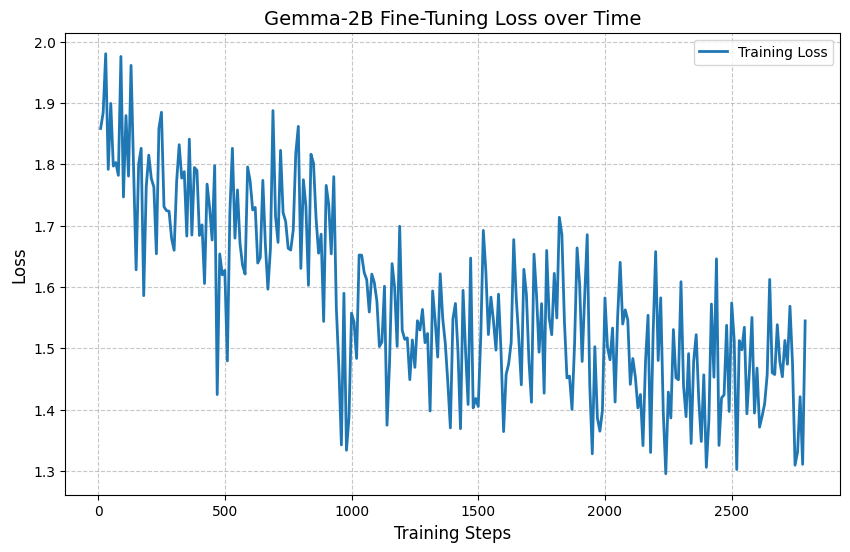

In [10]:
# Plot the losses

import json

log_history = trainer.state.log_history
training_logs = [log for log in log_history if 'loss' in log]

steps = [log['step'] for log in training_logs]
losses = [log['loss'] for log in training_logs]

loss_data = {'steps': steps, 'losses': losses}
with open('training_loss_history.json', 'w') as f:
    json.dump(loss_data, f, indent=2)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(steps, losses, label='Training Loss', linewidth=2)

plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Gemma-2B Fine-Tuning Loss over Time', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [11]:
# Upload training loss json to huggingface

from huggingface_hub import HfApi
api = HfApi()

repo_id = "bdanko/fine-tuned-gemma-2b-dolly"
local_file_name = "training_loss_history.json"
repo_destination = f"eval_results/{local_file_name}"

api.upload_file(
    path_or_fileobj=local_file_name,
    path_in_repo=repo_destination,
    repo_id=repo_id,
    repo_type="model" # Keep this as 'model' since you are uploading to a model repo
)

CommitInfo(commit_url='https://huggingface.co/bdanko/fine-tuned-gemma-2b-dolly/commit/17458eb136701db5bf268f8d7587ae5a8cdf5bfb', commit_message='Upload eval_results/training_loss_history.json with huggingface_hub', commit_description='', oid='17458eb136701db5bf268f8d7587ae5a8cdf5bfb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/bdanko/fine-tuned-gemma-2b-dolly', endpoint='https://huggingface.co', repo_type='model', repo_id='bdanko/fine-tuned-gemma-2b-dolly'), pr_revision=None, pr_num=None)

In [12]:
# test inference to check for
# model collapse in responses

import torch
model.eval()
model.config.use_cache = True

for i in range(3):
    sample = test_dolly[i]
    prompt = f'<start_of_turn>user\n{sample["instruction"]}'
    if sample.get("context"):
        prompt += f'\n\nContext: {sample["context"]}'
    prompt += "<end_of_turn>\n<start_of_turn>model\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=150, do_sample=False)

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True)

    print(f"\nSample {i+1}")
    print(f"Instruction: {sample['instruction']}")
    print(f"Response: {response}")


Sample 1
Instruction: When has the movie The Ride been released
Response: The Ride was released in 1996

Sample 2
Instruction: A client with whom you have been training for 10 weeks retakes a submaximal exercise test and finds that his heart rate is lower at each stage (workload) of the test. He is bothered by this because he thought his heart would be stronger and beat more times per minute. Brainstorm an easy-to-understand explanation to help him understand what is going on. How would you respond?
Response: The heart rate is a measure of the number of times the heart beats per minute. The heart rate is a measure of the heart's ability to pump blood. The heart rate is a measure of the heart's ability to pump blood at a given workload. The heart rate is a measure of the heart's ability to pump blood at a given workload. The heart rate is a measure of the heart's ability to pump blood at a given workload. The heart rate is a measure of the heart's ability to pump blood at a given workl

In [13]:
model.push_to_hub('bdanko/fine-tuned-gemma-2b-dolly')
tokenizer.push_to_hub('bdanko/fine-tuned-gemma-2b-dolly')

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...twq2abs/model.safetensors:   3%|3         |  152MB / 5.01GB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mptk7y1oyi/tokenizer.json: 100%|##########| 34.3MB / 34.3MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/bdanko/fine-tuned-gemma-2b-dolly/commit/e6984ff3c5ff1de6237790026279e8ec4c0c6f03', commit_message='Upload tokenizer', commit_description='', oid='e6984ff3c5ff1de6237790026279e8ec4c0c6f03', pr_url=None, repo_url=RepoUrl('https://huggingface.co/bdanko/fine-tuned-gemma-2b-dolly', endpoint='https://huggingface.co', repo_type='model', repo_id='bdanko/fine-tuned-gemma-2b-dolly'), pr_revision=None, pr_num=None)

In [14]:
# evaluations on the fine tuned model

ft_dolly_results  = generate_responses(model, tokenizer, test_dolly,  'ft_dolly_evals.json')
ft_alpaca_results = generate_responses(model, tokenizer, test_alpaca, 'ft_alpaca_evals.json')
print(f'FT Dolly evals: {len(ft_dolly_results)} | FT Alpaca evals: {len(ft_alpaca_results)}')

100%|██████████| 7/7 [00:44<00:00,  6.36s/it]

FT Dolly evals: 100 | FT Alpaca evals: 50


In [16]:
# uploading the responses to huggingface for saving

import json
from huggingface_hub import HfApi

eval_files = [
    'base_dolly_evals.json',
    'base_alpaca_evals.json',
    'ft_dolly_evals.json',
    'ft_alpaca_evals.json'
]
repo_id = "bdanko/fine-tuned-gemma-2b-dolly"
api = HfApi()

for filename in eval_files:
    try:
        with open(filename, 'r') as f:
            var_name = filename.replace('_evals.json', '_results')
            globals()[var_name] = json.load(f)

            api.upload_file(
                path_or_fileobj=filename,
                path_in_repo=f"eval_results/{filename}",
                repo_id=repo_id,
                repo_type="model"
            )
            print(f"Uploaded {filename} to {repo_id}/eval_results/")

    except FileNotFoundError:
        print(f"{filename} not found locally, skipping.")
    except Exception as e:
        print(f"Error processing {filename}: {e}")


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded base_dolly_evals.json to bdanko/fine-tuned-gemma-2b-dolly/eval_results/
Uploaded base_alpaca_evals.json to bdanko/fine-tuned-gemma-2b-dolly/eval_results/


No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded ft_dolly_evals.json to bdanko/fine-tuned-gemma-2b-dolly/eval_results/
Uploaded ft_alpaca_evals.json to bdanko/fine-tuned-gemma-2b-dolly/eval_results/


## LLM Judging

In [ ]:
from google.colab import userdata
import os

os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')

from huggingface_hub import login
login(token=os.environ['HF_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
# recollect base, fine tuned json evaluations from huggingface
# and save json responses locally
# for judging

from huggingface_hub import hf_hub_download
import json

repo_id = "bdanko/fine-tuned-gemma-2b-dolly"
eval_files = ['base_dolly_evals.json', 'base_alpaca_evals.json', 'ft_dolly_evals.json', 'ft_alpaca_evals.json']

for filename in eval_files:
    local_path = hf_hub_download(repo_id=repo_id, filename=f"eval_results/{filename}", repo_type="model")
    with open(local_path, 'r') as f:
        var_name = filename.replace('_evals.json', '_results')
        globals()[var_name] = json.load(f)

print(f"Loaded: {', '.join([f.replace('_evals.json', '_results') for f in eval_files])}")

base_dolly_evals.json: 0.00B [00:00, ?B/s]

base_alpaca_evals.json: 0.00B [00:00, ?B/s]

ft_dolly_evals.json: 0.00B [00:00, ?B/s]

ft_alpaca_evals.json: 0.00B [00:00, ?B/s]

Loaded: base_dolly_results, base_alpaca_results, ft_dolly_results, ft_alpaca_results


In [ ]:
import re
import pandas as pd
from tqdm import tqdm
import requests
import json

JUDGE_SYSTEM_PROMPT = '''You are an impartial judge evaluating the quality of an AI response. You will be provided with an instruction, a context (if applicable), and the AI\'s response.
Evaluation Process:
1. Step-by-Step Analysis: Critique the response based on the rubric.
2. Score Assignment: Provide a score for each metric (1-5).
3. Final Verdict: Justify why the scores were given.
Rubric:
Instruction Following: Did it do exactly what was asked? (5 = Perfect, 1 = Irrelevant)
Helpfulness: Is the information useful and correct? (5 = Insightful, 1 = Harmful/Useless)
Fluency: Is the text natural and grammatically sound? (5 = Native-level, 1 = Incoherent)
Please conclude your evaluation with a Markdown table and a brief \'Verdict\' section using the *exact* headers below:
```
## Final Scores
| Metric | Score |
| --- | --- |
| Instruction Following | [1-5] |
| Helpfulness | [1-5] |
| Fluency | [1-5] |
## Verdict
[One sentence summarizing the reasoning for the above scores]
```'''


def call_openrouter(model_name, api_key, instruction, context, response):
    url = 'https://openrouter.ai/api/v1/chat/completions'
    headers = {
        'Authorization': f'Bearer {api_key}',
        'Content-Type': 'application/json'
    }
    user_content = f'Instruction: {instruction}\nContext: {context}\nAI Response: {response}'
    payload = {
        'model': model_name,
        'messages': [
            {'role': 'system', 'content': JUDGE_SYSTEM_PROMPT},
            {'role': 'user', 'content': user_content}
        ]
    }
    res = requests.post(url, headers=headers, json=payload, timeout=60)
    res.raise_for_status()
    return res.json()['choices'][0]['message']['content']


def parse_judgement(judgement_text):
    """Robustly parse scores from the judge's markdown table."""
    scores = {}
    metric_keys = {
        'Instruction Following': 'instruction_following',
        'Helpfulness': 'helpfulness',
        'Fluency': 'fluency'
    }
    for label, key in metric_keys.items():
        pattern = rf'\|\s*{re.escape(label)}\s*\|\s*(\d)'
        match = re.search(pattern, judgement_text)
        if match:
            scores[key] = int(match.group(1))
        else:
            scores[key] = None
    return scores


In [ ]:
# run gpt5.2 and deepseek 3.2 via openrouter
# 10 concurrent threads

import json
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

api_key = os.environ['OPENROUTER_API_KEY']
JUDGES = ['openai/gpt-5.2', 'deepseek/deepseek-v3.2']
MAX_THREADS = 10
MAX_RETRIES = 3

all_evals = {
    'base_dolly':  base_dolly_results,
    'base_alpaca': base_alpaca_results,
    'ft_dolly':    ft_dolly_results,
    'ft_alpaca':   ft_alpaca_results,
}

def judge_item(key, res, judge):
    raw = ''
    scores = {'instruction_following': None, 'helpfulness': None, 'fluency': None}

    for attempt in range(MAX_RETRIES):
        try:
            raw = call_openrouter(
                judge, api_key,
                res['instruction'], res['context'], res['model_response']
            )
            scores = parse_judgement(raw)

            if all(v is not None for v in scores.values()):
                break
        except Exception as e:
            import time
            time.sleep(2)

    return {
        'key': key,
        'res_original': res,
        'judge': judge,
        'data': {'raw': raw, 'scores': scores}
    }

tasks = []
for key, results in all_evals.items():
    for res in results:
        for judge in JUDGES:
            tasks.append((key, res, judge))

raw_results = []
with ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
    futures = [executor.submit(judge_item, *t) for t in tasks]
    for future in tqdm(as_completed(futures), total=len(futures), desc="Judging Tasks"):
        raw_results.append(future.result())

judgement_results = {key: [] for key in all_evals.keys()}
temp_storage = {}

for item in raw_results:
    key = item['key']
    res = item['res_original']
    judge = item['judge']

    # Hash the full instruction and full context to guarantee uniqueness
    prompt_id = hash(f"{key}_{res['instruction']}_{res['context']}")

    if prompt_id not in temp_storage:
        temp_storage[prompt_id] = {
            'instruction': res['instruction'],
            'context': res['context'],
            'model_response': res['model_response'],
            'judgements': {},
            'category_key': key
        }

    temp_storage[prompt_id]['judgements'][judge] = item['data']

for val in temp_storage.values():
    category = val.pop('category_key')
    judgement_results[category].append(val)

with open('judgement_results.json', 'w') as f:
    json.dump(judgement_results, f, indent=2)

print('Judging complete.')

Judging Tasks: 100%|██████████| 600/600 [10:19<00:00,  1.03s/it]

Judging complete.


In [ ]:
# check for total number of judge evaluations to confirm
# that we judged each row correctly

def print_counts(results_dict, judges):
    print(f"{'Category':<15} | {'Prompts':<8} | {judges[0]:<15} | {judges[1]:<15}")
    print("-" * 65)
    for category, entries in results_dict.items():
        prompt_count = len(entries)
        judge_counts = []
        for judge in judges:
            count = sum(1 for e in entries
                        if judge in e['judgements']
                        and e['judgements'][judge]['scores'].get('instruction_following') is not None)
            judge_counts.append(count)
        print(f"{category:<15} | {prompt_count:<8} | {judge_counts[0]:<15} | {judge_counts[1]:<15}")

print_counts(judgement_results, JUDGES)

Category        | Prompts  | openai/gpt-5.2  | deepseek/deepseek-v3.2
-----------------------------------------------------------------
base_dolly      | 98       | 98              | 98             
base_alpaca     | 50       | 50              | 50             
ft_dolly        | 100      | 100             | 100            
ft_alpaca       | 50       | 50              | 49             


In [ ]:
import time

def retry_judgements(results_dict, judges, max_retries=5):

    total_fixed = 0

    for category, entries in results_dict.items():

        for entry in entries:
            for judge in judges:

                current_judgement = entry['judgements'].get(judge, {})
                scores = current_judgement.get('scores', {})

                if not scores or any(v is None for v in scores.values()):
                    print(f"[MISSING] {judge} | Instruction: {entry['instruction'][:50]}...")

                    # Retry
                    success = False
                    for attempt in range(max_retries):
                        try:
                            raw = call_openrouter(
                                judge, api_key,
                                entry['instruction'], entry['context'], entry['model_response']
                            )
                            new_scores = parse_judgement(raw)

                            if all(v is not None for v in new_scores.values()):
                                entry['judgements'][judge] = {'raw': raw, 'scores': new_scores}
                                print(f"Success on attempt {attempt + 1}")
                                total_fixed += 1
                                success = True
                                break
                        except Exception as e:
                            wait_time = (attempt + 1) * 4  # Linear backoff
                            print(f"Attempt {attempt + 1} failed: {e}. Retrying in {wait_time}s...")
                            time.sleep(wait_time)

                    if not success:
                        print(f"Failed to recover judgement for {judge} after {max_retries} attempts.")

    print(f"\nFixed {total_fixed} missing entries.")
    return results_dict

judgement_results = retry_judgements(judgement_results, JUDGES)

[MISSING] deepseek/deepseek-v3.2 | Instruction: Create the heading for a news article about the im...
Success on attempt 1

Fixed 1 missing entries.


In [ ]:
# check for total number of judge evaluations to confirm
# that we judged each row correctly

def print_counts(results_dict, judges):
    print(f"{'Category':<15} | {'Prompts':<8} | {judges[0]:<15} | {judges[1]:<15}")
    print("-" * 65)
    for category, entries in results_dict.items():
        prompt_count = len(entries)
        judge_counts = []
        for judge in judges:
            count = sum(1 for e in entries
                        if judge in e['judgements']
                        and e['judgements'][judge]['scores'].get('instruction_following') is not None)
            judge_counts.append(count)
        print(f"{category:<15} | {prompt_count:<8} | {judge_counts[0]:<15} | {judge_counts[1]:<15}")

print_counts(judgement_results, JUDGES)

Category        | Prompts  | openai/gpt-5.2  | deepseek/deepseek-v3.2
-----------------------------------------------------------------
base_dolly      | 98       | 98              | 98             
base_alpaca     | 50       | 50              | 50             
ft_dolly        | 100      | 100             | 100            
ft_alpaca       | 50       | 50              | 50             


NameError: name 'test_dolly' is not defined

In [ ]:
summary_data = []
for key, entries in judgement_results.items():
    model_label = 'base' if 'base' in key else 'fine-tuned'
    dist_label  = 'in'   if 'dolly' in key else 'out'
    for judge in JUDGES:
        valid = [e for e in entries if e['judgements'][judge]['scores']['instruction_following'] is not None]
        n = len(valid) or 1
        avg_if = sum(e['judgements'][judge]['scores']['instruction_following'] for e in valid) / n
        avg_h  = sum(e['judgements'][judge]['scores']['helpfulness']           for e in valid) / n
        avg_f  = sum(e['judgements'][judge]['scores']['fluency']               for e in valid) / n
        summary_data.append({
            'Model':                 model_label,
            'Distribution':          dist_label,
            'Judge':                 judge,
            'Instruction Following': round(avg_if, 2),
            'Helpfulness':           round(avg_h,  2),
            'Fluency':               round(avg_f,  2),
        })

df = pd.DataFrame(summary_data)
df = df.sort_values(['Model', 'Distribution', 'Judge']).reset_index(drop=True)
print(df.to_markdown(index=False))

| Model      | Distribution   | Judge                  |   Instruction Following |   Helpfulness |   Fluency |
|:-----------|:---------------|:-----------------------|------------------------:|--------------:|----------:|
| base       | in             | deepseek/deepseek-v3.2 |                    3.71 |          3.39 |      4.86 |
| base       | in             | openai/gpt-5.2         |                    3.66 |          2.92 |      4.78 |
| base       | out            | deepseek/deepseek-v3.2 |                    3.56 |          3.42 |      4.86 |
| base       | out            | openai/gpt-5.2         |                    3.52 |          3.04 |      4.9  |
| fine-tuned | in             | deepseek/deepseek-v3.2 |                    3.63 |          3.16 |      4.69 |
| fine-tuned | in             | openai/gpt-5.2         |                    3.61 |          2.85 |      4.55 |
| fine-tuned | out            | deepseek/deepseek-v3.2 |                    3.04 |          2.86 |      4.62 |
|

In [ ]:
from huggingface_hub import HfApi
from datasets import Dataset
import json

def upload_judgements(judgement_list, judge_name, repo_id):
    rows = []
    for entry in judgement_list:
        j = entry['judgements'].get(judge_name, {})
        rows.append({
            'instruction':            entry['instruction'],
            'context':                entry['context'],
            'model_response':         entry['model_response'],
            'raw_judgement':          j.get('raw', ''),
            'instruction_following':  j.get('scores', {}).get('instruction_following'),
            'helpfulness':            j.get('scores', {}).get('helpfulness'),
            'fluency':                j.get('scores', {}).get('fluency'),
        })

    model_repo = "bdanko/fine-tuned-gemma-2b-dolly"
    filename = f"{repo_id.split('/')[-1]}.json"

    with open(filename, 'w') as f:
        json.dump(rows, f, indent=2)

    api = HfApi()
    api.upload_file(
        path_or_fileobj=filename,
        path_in_repo=f"eval_results/{filename}",
        repo_id=model_repo,
        repo_type="model"
    )

    print(f'Uploaded JSON to {model_repo}/eval_results/{filename}')

upload_judgements(judgement_results['base_dolly'],  'openai/gpt-5.2',
                  'bdanko/base-gemma-2b-dolly-evaluation-gpt-5.2-judgement')
upload_judgements(judgement_results['base_dolly'],  'deepseek/deepseek-v3.2',
                  'bdanko/base-gemma-2b-dolly-evaluation-deepseek-v3.2-judgement')
upload_judgements(judgement_results['base_alpaca'], 'openai/gpt-5.2',
                  'bdanko/base-gemma-2b-alpaca-evaluation-gpt-5.2-judgement')
upload_judgements(judgement_results['base_alpaca'], 'deepseek/deepseek-v3.2',
                  'bdanko/base-gemma-2b-alpaca-evaluation-deepseek-v3.2-judgement')
upload_judgements(judgement_results['ft_dolly'],    'openai/gpt-5.2',
                  'bdanko/fine-tuned-gemma-2b-dolly-evaluation-gpt-5.2-judgement')
upload_judgements(judgement_results['ft_dolly'],    'deepseek/deepseek-v3.2',
                  'bdanko/fine-tuned-gemma-2b-dolly-evaluation-deepseek-v3.2-judgement')
upload_judgements(judgement_results['ft_alpaca'],   'openai/gpt-5.2',
                  'bdanko/fine-tuned-gemma-2b-alpaca-evaluation-gpt-5.2-judgement')
upload_judgements(judgement_results['ft_alpaca'],   'deepseek/deepseek-v3.2',
                  'bdanko/fine-tuned-gemma-2b-alpaca-evaluation-deepseek-v3.2-judgement')

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/base-gemma-2b-dolly-evaluation-gpt-5.2-judgement.json
Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/base-gemma-2b-dolly-evaluation-deepseek-v3.2-judgement.json
Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/base-gemma-2b-alpaca-evaluation-gpt-5.2-judgement.json


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/base-gemma-2b-alpaca-evaluation-deepseek-v3.2-judgement.json
Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/fine-tuned-gemma-2b-dolly-evaluation-gpt-5.2-judgement.json
Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/fine-tuned-gemma-2b-dolly-evaluation-deepseek-v3.2-judgement.json


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/fine-tuned-gemma-2b-alpaca-evaluation-gpt-5.2-judgement.json
Uploaded JSON to bdanko/fine-tuned-gemma-2b-dolly/eval_results/fine-tuned-gemma-2b-alpaca-evaluation-deepseek-v3.2-judgement.json


In [ ]:
# Compare avg score across both judges: base vs fine-tuned

def avg_score(entry, judge):
    s = entry['judgements'][judge]['scores']
    vals = [v for v in s.values() if v is not None]
    return sum(vals) / len(vals) if vals else 0


def total_avg(entry):
    return sum(avg_score(entry, j) for j in JUDGES) / len(JUDGES)


base_lookup = {e['instruction']: e for e in judgement_results['base_dolly']}
ft_lookup   = {e['instruction']: e for e in judgement_results['ft_dolly']}

deltas = []
for instr, ft_entry in ft_lookup.items():
    if instr in base_lookup:
        base_score = total_avg(base_lookup[instr])
        ft_score   = total_avg(ft_entry)
        deltas.append((ft_score - base_score, instr, base_lookup[instr], ft_entry))

deltas.sort(key=lambda x: x[0], reverse=True)

print('=== TOP 3 IMPROVEMENT CASES ===')
for delta, instr, base_e, ft_e in deltas[:3]:
    print(f'\nDelta: +{delta:.2f}')
    print(f'Instruction: {instr[:120]}')
    print(f'Base response: {base_e["model_response"][:300]}')
    print(f'FT response:   {ft_e["model_response"][:300]}')
    print('---')

print('\n=== FAILURE CASE (largest regression) ===')
delta, instr, base_e, ft_e = deltas[-1]
print(f'Delta: {delta:.2f}')
print(f'Instruction: {instr[:120]}')
print(f'Base response: {base_e["model_response"][:300]}')
print(f'FT response:   {ft_e["model_response"][:300]}')

=== TOP 3 IMPROVEMENT CASES ===

Delta: +2.17
Instruction: Write a response to a veteran interested in renting my house
Base response: Sure, I can help you with that. Please provide me with the instruction and the relevant context, and I will respond in a helpful, accurate, and concise manner.
FT response:   Thank you for your interest in my house. I will be happy to schedule a showing at your convenience. I look forward to hearing from you.
---

Delta: +2.17
Instruction: Identify which instrument is string or percussion: Fontomfrom, Ruan
Base response: Sure, here's the response to your instruction:

The instrument Fontomfrom is a percussion instrument, while the Ruan is a string instrument.
FT response:   Ruan is string, Fontomfrom is percussion.
---

Delta: +1.83
Instruction: Tell me if these are body parts or places: nose, beach, supermarket, feet, eyes, hand, mall, school, restaurant, heart
Base response: Sure, here's the response to your instruction:

The words "nose, beach, super

### Improvement Cases

> Fill in after running the cell above. Copy the top 3 improvement examples here with explanation.

1. **Case 1**: [Instruction] — Base model [description of failure]. Fine-tuned model [description of improvement]. Root cause: domain alignment.
2. **Case 2**: [Instruction] — ...
3. **Case 3**: [Instruction] — ...

### Failure Case

> Fill in after running the cell above. Copy the bottom regression example here.

1. **Failure**: [Instruction] — Fine-tuned model scored lower than base. Root cause: [e.g. catastrophic forgetting on long-form reasoning / over-fitting to Dolly response style / ...]